# Notebook 04 — Supervised Classification of Market Regimes

The HMM (Notebook 03) detected 3 market regimes in an unsupervised manner.
In this notebook we train a supervised classifier that learns to predict
the current regime from observable technical indicators.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,
                             ConfusionMatrixDisplay,
                            f1_score,accuracy_score,
                            precision_score,
                              recall_score)
from xgboost import XGBClassifier

plt.style.use('dark_background')
print("Imports OK")

Imports OK


###  4.1 Load the data and preparated features

In [5]:
btc = pd.read_csv('../data/raw/btc_regimes.csv', index_col=0, parse_dates=True)
print("Shape:", btc.shape)
print("\nColumns:", btc.columns.tolist())
print('\n')
print(btc['regime_label'].value_counts())

Shape: (2957, 7)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'regime', 'regime_label']


regime_label
Sideways    1093
Bull        1035
Bear         829
Name: count, dtype: int64


##### 4.1.1 Define Features (X) and Target (y)


In [6]:
features = ['log_returns', 'volatility_7d', 'volatility_21d', 
            'rsi', 'macd_diff', 'volume_norm']
btc_features= pd.read_csv('../data/raw/btc_features_clean.csv', 
                            index_col=0, parse_dates=True)
btc_features= btc_features.loc[btc.index]

#Prepared
X= btc_features[features]
y = btc['regime_label']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClasses:", y.unique())


X shape: (2957, 6)
y shape: (2957,)

Classes: <StringArray>
['Bear', 'Sideways', 'Bull']
Length: 3, dtype: str


In [9]:
# 80% train / 20% test split by date
split_idx = int(len(X) * 0.80)
split_date = X.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(y_train.value_counts())
print(y_test.value_counts())

regime_label
Sideways    1023
Bear         721
Bull         621
Name: count, dtype: int64
regime_label
Bull        414
Bear        108
Sideways     70
Name: count, dtype: int64


### 4.2 Random Forest Classifier

In [10]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth= 10,
                            min_samples_leaf=20,
                            class_weight='balanced',
                            random_state=42)

rf.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### 4.4 Model Evaluation

In [16]:
y_pred = rf.predict(X_test)
print("=" * 53)
print(" " * 17+"CLASSIFICATION REPORT")
print("=" * 53)
print(classification_report(y_test, y_pred))

print(f"Overall Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro F1 Score:    {f1_score(y_test, y_pred, average='macro'):.3f}")

                 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Bear       0.96      0.67      0.79       108
        Bull       0.93      0.79      0.85       414
    Sideways       0.41      0.97      0.58        70

    accuracy                           0.79       592
   macro avg       0.77      0.81      0.74       592
weighted avg       0.88      0.79      0.81       592

Overall Accuracy:  0.789
Macro F1 Score:    0.739


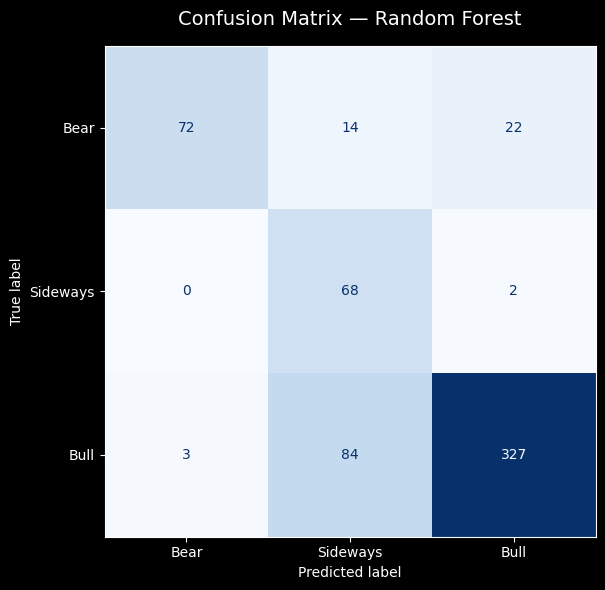

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred, labels=['Bear', 'Sideways', 'Bull'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Bear', 'Sideways', 'Bull'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — Random Forest', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


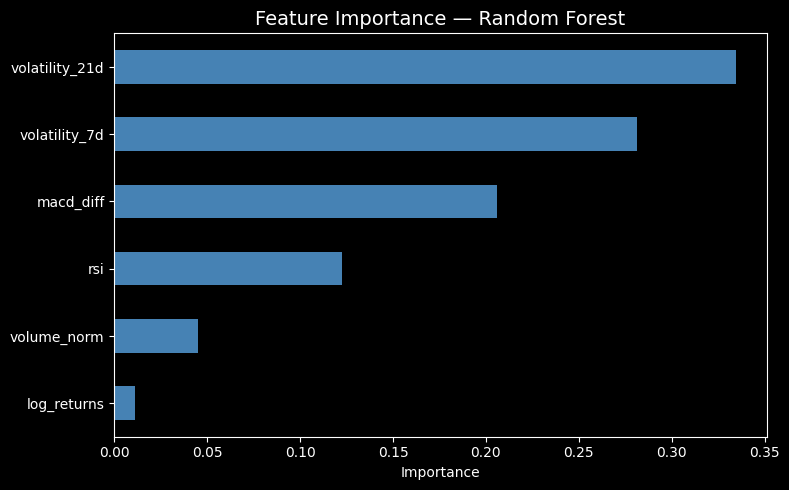


Feature Importance (ranked):
volatility_21d    0.3344
volatility_7d     0.2812
macd_diff         0.2060
rsi               0.1224
volume_norm       0.0451
log_returns       0.0110
dtype: float64


In [21]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nFeature Importance (ranked):")
print(importances.sort_values(ascending=False).round(4))

### 4.3 XGBoost Classifier

In [28]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train_enc)



Label mapping:
  0 → Bear
  1 → Bull
  2 → Sideways


/home/sebastian14/dev/Sebasduarte14/DataScience/crypto-market-regime-detection/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:16:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [30]:
y_pred_xgb = xgb_model.predict(X_test)

y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print("=" * 50)
print("XGBOOST — CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb_labels))

XGBOOST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Bear       0.97      0.77      0.86       108
        Bull       0.94      0.85      0.89       414
    Sideways       0.54      1.00      0.70        70

    accuracy                           0.85       592
   macro avg       0.81      0.87      0.82       592
weighted avg       0.90      0.85      0.86       592



### 4.5 Finance Backtesting

In [39]:
backtest = pd.DataFrame(index=X_test.index)
backtest['close'] = btc.loc[X_test.index, 'Close']
backtest['actual_regime'] = y_test.values
backtest['predicted_regime'] = y_pred_xgb_labels
backtest['daily_return'] = backtest['close'].pct_change().fillna(0)

# Strategy: invested only when model predicts Bull
backtest['in_market'] = (backtest['predicted_regime'] == 'Bull').astype(int)
backtest['strategy_return'] = backtest['daily_return'] * backtest['in_market']

# Cumulative returns
backtest['buy_hold_cum'] = (1 + backtest['daily_return']).cumprod()
backtest['strategy_cum'] = (1 + backtest['strategy_return']).cumprod()

print(backtest.head(10))


                   close actual_regime predicted_regime  daily_return  \
Date                                                                    
2024-07-26  67912.062500          Bull             Bull      0.000000   
2024-07-27  67813.335938          Bull             Bull     -0.001454   
2024-07-28  68255.867188          Bull             Bull      0.006526   
2024-07-29  66819.914062          Bull             Bull     -0.021038   
2024-07-30  66201.015625          Bull         Sideways     -0.009262   
2024-07-31  64619.250000          Bull         Sideways     -0.023893   
2024-08-01  65357.500000          Bull         Sideways      0.011425   
2024-08-02  61415.066406          Bull             Bull     -0.060321   
2024-08-03  60680.093750          Bull             Bull     -0.011967   
2024-08-04  58116.976562          Bull             Bull     -0.042240   

            in_market  strategy_return  buy_hold_cum  strategy_cum  
Date                                                  

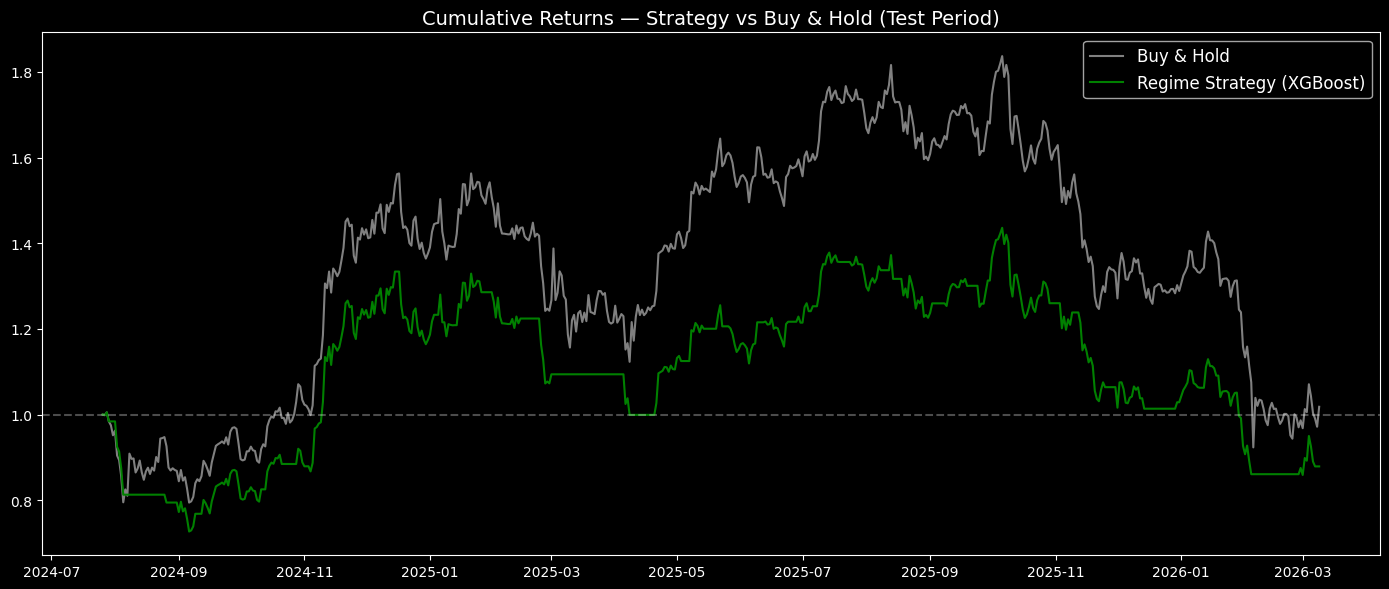

Buy & Hold return:1.8%
Strategy return-12.1%
Difference:-13.9%


In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(backtest.index, backtest['buy_hold_cum'], 
        label='Buy & Hold', color='gray', linewidth=1.5)
ax.plot(backtest.index, backtest['strategy_cum'], 
        label='Regime Strategy (XGBoost)', color='green', linewidth=1.5)

ax.set_title('Cumulative Returns — Strategy vs Buy & Hold (Test Period)', fontsize=14)
ax.legend(fontsize=12)
ax.axhline(y=1, color='white', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

final_bh = backtest['buy_hold_cum'].iloc[-1]
final_strat = backtest['strategy_cum'].iloc[-1]

print(f"Buy & Hold return:{(final_bh - 1)*100:.1f}%")
print(f"Strategy return{(final_strat - 1)*100:.1f}%")
print(f"Difference:{(final_strat - final_bh)*100:.1f}%")


In [40]:
import joblib

joblib.dump(rf, '../data/raw/rf_model.pkl')
joblib.dump(xgb_model, '../data/raw/xgb_model.pkl')
joblib.dump(le, '../data/raw/label_encoder.pkl')

print("Models saved:")
print("  - rf_model.pkl")
print("  - xgb_model.pkl")
print("  - label_encoder.pkl")


Models saved:
  - rf_model.pkl
  - xgb_model.pkl
  - label_encoder.pkl
